In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df=pd.read_csv('bostonhousing.csv')

In [3]:
df.shape

(506, 14)

In [4]:
df.dtypes

Crime_rate    float64
zn            float64
indus         float64
chas            int64
nox           float64
rm            float64
Age           float64
Distance      float64
rad             int64
tax             int64
ptratio       float64
b             float64
lstat         float64
medv          float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Crime_rate  506 non-null    float64
 1   zn          506 non-null    float64
 2   indus       506 non-null    float64
 3   chas        506 non-null    int64  
 4   nox         506 non-null    float64
 5   rm          501 non-null    float64
 6   Age         506 non-null    float64
 7   Distance    506 non-null    float64
 8   rad         506 non-null    int64  
 9   tax         506 non-null    int64  
 10  ptratio     506 non-null    float64
 11  b           506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.describe()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
int(df.duplicated().sum())

0

In [8]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            5
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

In [9]:
df['rm']=df['rm'].fillna(df['rm'].mean())

In [10]:
df.isnull().sum()

Crime_rate    0
zn            0
indus         0
chas          0
nox           0
rm            0
Age           0
Distance      0
rad           0
tax           0
ptratio       0
b             0
lstat         0
medv          0
dtype: int64

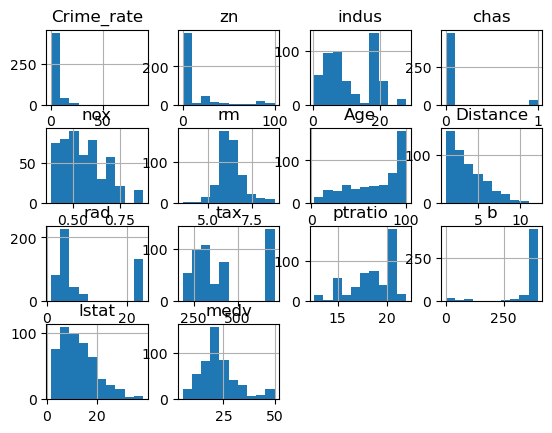

In [11]:
df.hist()
plt.show()

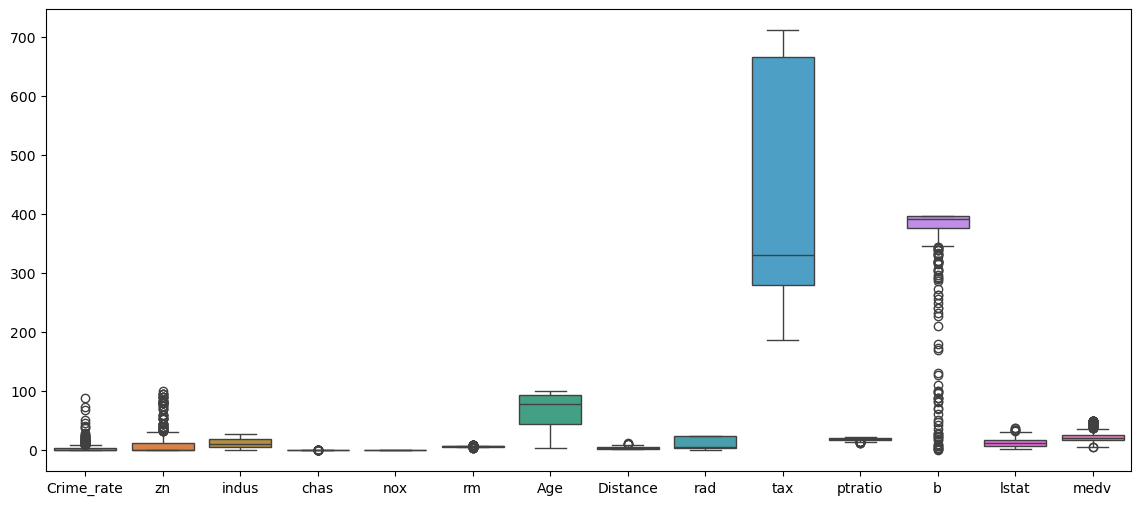

In [12]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.show()

In [13]:
cols=['Crime_rate','zn','rm','Distance','ptratio','b','lstat','medv']
for col in cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower_bound=q1-1.5*iqr
    upper_bound=q3+1.5*iqr

    df[col]=df[col].where(df[col]>lower_bound,lower_bound)
    df[col]=df[col].where(df[col]<upper_bound,upper_bound)

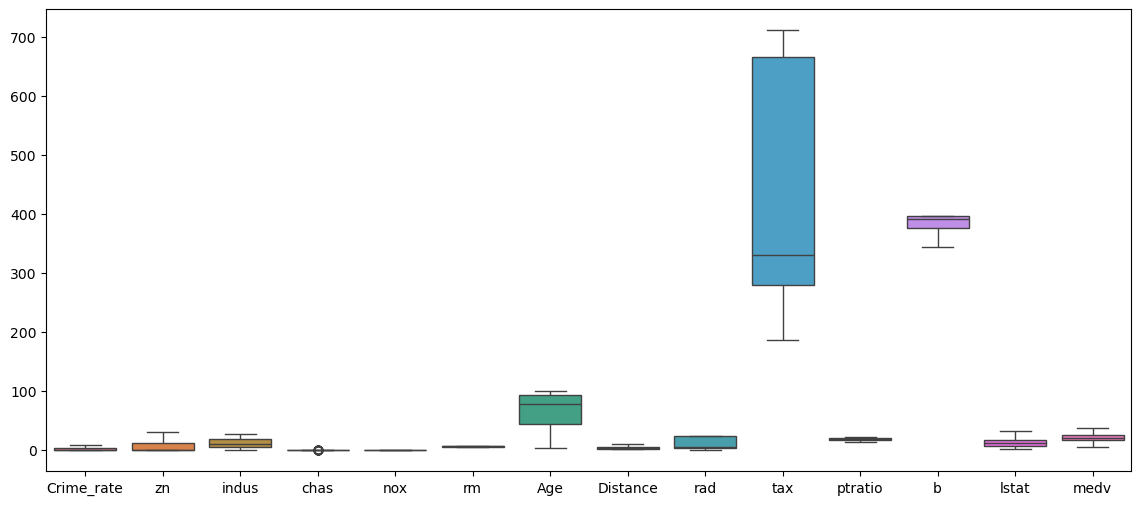

In [14]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.show()

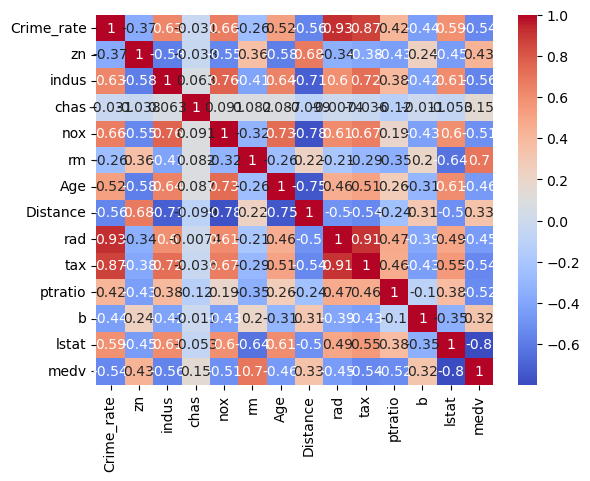

In [15]:
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [16]:
x=df.drop(columns=["medv"])
y=df["medv"]

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=22)

Suppose you define:

“normal body temperature” based on many people = 98.6°F

Now a new patient comes with 102°F.

You compare against the known standard.

You do NOT redefine “normal” using that one patient.

Same idea.

fit() = learning
transform() = using what was learned

We only learn from training data.

We never learn from test data.

In [18]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)

x_test_scaled=ss.transform(x_test)

In [19]:
model=LinearRegression()

In [20]:
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
pred=model.predict(x_test_scaled)

In [22]:
print(pred)

[26.2472575  30.07959625 21.43121652 30.54569664 19.6673049  17.45088883
 21.43568955 20.38971452 20.37903316 30.03218871 21.38729657 25.3061275
 15.47717485 18.92608352 32.22989893 18.24606569  9.49524474 18.08178359
 29.33817826 24.64166057 18.17624582 31.04703271 27.75319968 15.52333814
 32.11751101 25.98971677 31.40220801 27.72988004 16.15497873 17.20084876
 28.43058664 14.70168974 33.54442912 13.88876668 16.07047118 17.02657311
  7.9700746  18.92375178 37.67460638 28.47614063 25.01831678 16.51740543
 32.10242566  5.87372563 21.22307354 25.12485536 19.76148469 19.59754692
 16.82862945 22.41697299 10.0660476  26.75480224 29.0650776  14.58068272
 10.7813616  32.5199829  28.9460719  23.27609338 17.84352397 23.15770756
 23.59327072 24.90566765 20.39179995 35.58939963 25.62373338 18.06094265
 13.60714837  6.94374504 35.10598064 22.5305038  17.39415288 23.31393232
 34.76869048 22.48636948 33.69823729 25.99719487 21.65488243 22.68005299
 25.64534709 23.19229499 29.65731694 20.87340812 23.

In [23]:
mean_squared_error(y_test,pred)

12.726155939660691

In [24]:
r2_score(y_test,pred)

0.7871366589703549

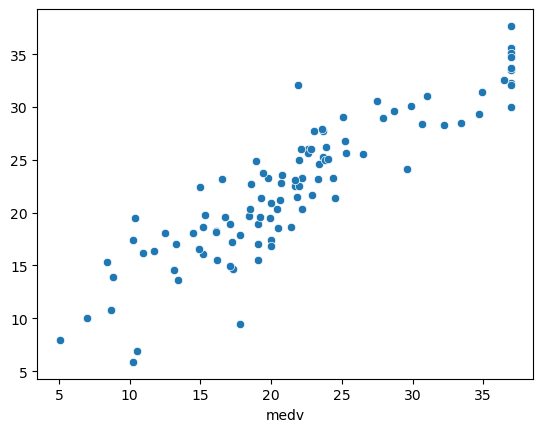

In [25]:
sns.scatterplot(x=y_test,y=pred)
plt.show()

In [26]:
sample_input=[[1.6566,0,19.58,0,0.871,6.122,97.3,1.618,5,403,14.7,372.8,14.1]]
scaled=ss.transform(sample_input)
output=model.predict(scaled)
print(output[0])

19.522778781197324


/usr/lib/python3/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
